In [12]:
# 1. Instalación de dependencias del proyecto
%pip install pandas numpy openpyxl matplotlib seaborn streamlit

Note: you may need to restart the kernel to use updated packages.


In [13]:
# 2. Importar librerias
import pandas as pd
import numpy as np
import os
import glob

In [14]:
# 3. Configuración de semilla aleatoria y formato visual
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [16]:
# 4. Detección y carga automática del archivo de datos
archivos_encontrados = glob.glob("bienestar_laboral_limpio*")
if not archivos_encontrados:
    raise FileNotFoundError("No se encontró el archivo de la base de datos en esta carpeta.")

In [18]:
# ==============================================================================
# BLOQUE 1: CONFIGURACIÓN, CARGA DE EXCEL Y VERIFICACIÓN
# ==============================================================================

import pandas as pd
import numpy as np
import os
import glob

# 1. Configuración de semilla aleatoria y formato visual
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# 2. Detección y carga automática en formato Excel
archivos_encontrados = glob.glob("bienestar_laboral_limpio*")
if not archivos_encontrados:
    raise FileNotFoundError("No se encontró el archivo de la base de datos en esta carpeta.")

data_path = archivos_encontrados[0]
df_raw = pd.read_excel(data_path)

# 3. Depuración de nombres y eliminación de columnas duplicadas
df = df_raw.loc[:, ~df_raw.columns.duplicated(keep='first')].copy()
df.columns = df.columns.str.strip()

# 4. Inspección estructural y visualización inicial
print(df.info())
display(df.head(3))

# 5. Verificación automática de dimensiones en formato Excel
assert df.shape[0] == 400, f"Error: Se esperaban 400 registros, pero se encontraron {df.shape[0]}."
assert 'Edad' in df.columns, "Error: La columna 'Edad' es indispensable y no fue encontrada."

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 48 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  400 non-null    int64  
 1   Edad                400 non-null    int64  
 2   Sexo                400 non-null    object 
 3   Estado_Civil        400 non-null    object 
 4   Numero_Hijos        400 non-null    object 
 5   Nivel_Educativo     400 non-null    object 
 6   Zona_Vivienda       400 non-null    object 
 7   Estrato             400 non-null    int64  
 8   Sector              400 non-null    object 
 9   Tamaño_Empresa      400 non-null    object 
 10  Trabajo_Turnos      400 non-null    object 
 11  Tipo_Contrato       400 non-null    object 
 12  Horas_Semana        400 non-null    int64  
 13  Ingreso             400 non-null    object 
 14  Tipo_Cargo          400 non-null    object 
 15  Personas_Cargo      400 non-null    object 
 16  Años_Exp

,ID,Edad,Sexo,Estado_Civil,Numero_Hijos,Nivel_Educativo,Zona_Vivienda,Estrato,Sector,Tamaño_Empresa,Trabajo_Turnos,Tipo_Contrato,Horas_Semana,Ingreso,Tipo_Cargo,Personas_Cargo,Años_Experiencia,Antiguedad_Cargo,Modalidad,Horas_Traslado,Horas_Formacion,PRESION_TIEMPO,COMPROMISO_LIDER,APOYO_COMP,CONFLICTO_ROL,GESTION_CAMBIO,SALUD_MENTAL_ORG,INTENCION_RETIRO,CONF_FAM_TRAB,CONF_TRAB_FAM,BIENESTAR,DESGASTE,CTRL,PRESION_TIEMPO.1,COMPROMISO_LIDER.1,APOYO_COMP.1,CLARIDAD_ROL,CONFLICTO_ROL.1,GESTION_CAMBIO.1,SALUD_MENTAL_ORG.1,SATISFACCION,INTENCION_RETIRO.1,CONF_FAM_TRAB.1,CONF_TRAB_FAM.1,BURNOUT,BIENESTAR.1,SOMATIZACION,DESGASTE.1
0,1,47,Mujer,Casado,Sin hijos,Profesional,Urbana,2,Mixto,Más de 500 empleados,No,Presentación de servicios,48,Entre 1 y 3 SMLV,Operativo,No,Entre 1 a 5,Entre 1 y 3 años,Presencial,Entre 2 y 3 horas,9,3.000,2.429,4.000,2.000,2.250,2.400,2.250,1.200,1.600,5.200,2.000,2.333,3.000,2.429,4.000,4.750,2.000,2.250,2.400,5.778,2.250,1.200,1.600,1.833,5.200,2.000,2.000
1,2,43,Mujer,Separado,3,Profesional,Urbana,3,Público,Más de 500 empleados,Si,Provisionalidad,45,Entre 1 y 3 SMLV,Administrativo,No,Entre 20 a 25,Entre 1 y 3 años,Presencial,Menos de 1 hora,29,2.500,2.857,4.333,2.333,1.750,2.600,4.000,1.600,4.800,5.200,1.125,4.000,2.500,2.857,4.333,4.500,2.333,1.750,2.600,5.000,4.000,1.600,4.800,1.833,5.200,2.400,1.125
2,3,54,Mujer,Soltero,2,Profesional,Urbana,4,Público,Entre 50 y 200 empleados,No,Carrera,43,Entre 1 y 3 SMLV,Directivo,No,Entre 5 a 10,Entre 3 y 7 años,Presencial,Menos de 1 hora,81,3.250,4.429,2.333,2.000,3.750,2.200,1.000,3.400,2.200,5.600,1.250,3.000,3.250,4.429,2.333,4.500,2.000,3.750,2.200,6.222,1.000,3.400,2.200,2.083,5.600,4.600,1.250


In [34]:
# Analisis univariado

print(" INICIANDO ANÁLISIS UNIVARIADO (Evaluación de variables aisladas)...")

# 1. Resumen univariado cualitativo (Variables sociodemográficas)
variables_cat = ['Sexo', 'Nivel_Educativo', 'Sector', 'Modalidad']
for col in variables_cat:
    frec_abs = df[col].value_counts()
    frec_rel = df[col].value_counts(normalize=True) * 100
    df_uni_cat = pd.DataFrame({'N': frec_abs, 'Porcentaje (%)': frec_rel})
    print(f"\n🔹 Distribución Univariada: {col}")
    display(df_uni_cat)

# 2. Resumen univariado cuantitativo avanzado (Métricas de forma)
col_bienestar = 'BIENESTAR.1' if 'BIENESTAR.1' in df.columns else 'BIENESTAR'
col_burnout = 'BURNOUT.1' if 'BURNOUT.1' in df.columns else 'BURNOUT'
col_desgaste = 'DESGASTE.1' if 'DESGASTE.1' in df.columns else 'DESGASTE'

df_uni_num = df[['Edad', col_bienestar, col_burnout, col_desgaste]].describe().T
df_uni_num['Asimetría'] = df[['Edad', col_bienestar, col_burnout, col_desgaste]].skew()
df_uni_num['Curtosis'] = df[['Edad', col_bienestar, col_burnout, col_desgaste]].kurt()

print("\n🔹 Métricas Univariadas de Tendencia Central y Forma:")
display(df_uni_num[['mean', '50%', 'std', 'Asimetría', 'Curtosis']])

 INICIANDO ANÁLISIS UNIVARIADO (Evaluación de variables aisladas)...

🔹 Distribución Univariada: Sexo


,N,Porcentaje (%)
Sexo,,
Mujer,258,64.500
Hombre,141,35.250
Prefiero no decir,1,0.250



🔹 Distribución Univariada: Nivel_Educativo


,N,Porcentaje (%)
Nivel_Educativo,,
Posgrado,153,38.250
Profesional,96,24.000
Técnico,69,17.250
Tecnológico,52,13.000
Bachiller,28,7.000
Primaria,2,0.500



🔹 Distribución Univariada: Sector


,N,Porcentaje (%)
Sector,,
Público,309,77.250
Mixto,91,22.750



🔹 Distribución Univariada: Modalidad


,N,Porcentaje (%)
Modalidad,,
Presencial,368,92.000
Híbrido,32,8.000



🔹 Métricas Univariadas de Tendencia Central y Forma:


,mean,50%,std,Asimetría,Curtosis
Edad,41.285,41.500,9.796,0.024,-0.378
BIENESTAR.1,5.207,5.400,1.184,-0.542,-0.520
BURNOUT,2.359,2.250,0.983,0.600,-0.556
DESGASTE.1,2.941,2.750,1.374,0.633,-0.381


In [40]:
# Analisis bivariado

print(" INICIANDO ANÁLISIS BIVARIADO ")

# 1. Definición de dimensiones para cruces bivariados
col_satisfaccion = 'SATISFACCION.1' if 'SATISFACCION.1' in df.columns else 'SATISFACCION'
col_lider = 'COMPROMISO_LIDER.1' if 'COMPROMISO_LIDER.1' in df.columns else 'COMPROMISO_LIDER'

variables_bivariado = [col_bienestar, col_burnout, col_desgaste, col_satisfaccion, col_lider]

# 2. Construcción de la matriz bivariada base
matriz_bivariada = df[variables_bivariado].corr()
matriz_bivariada.index = [idx.replace('.1', '') for idx in matriz_bivariada.index]
matriz_bivariada.columns = [col.replace('.1', '') for col in matriz_bivariada.columns]

print("\n Matriz Bivariada de Correlación Cruzada:")
display(matriz_bivariada)

 INICIANDO ANÁLISIS BIVARIADO 

 Matriz Bivariada de Correlación Cruzada:


,BIENESTAR,BURNOUT,DESGASTE,SATISFACCION,COMPROMISO_LIDER
BIENESTAR,1.000,-0.681,-0.625,0.652,0.561
BURNOUT,-0.681,1.000,0.658,-0.622,-0.533
DESGASTE,-0.625,0.658,1.000,-0.611,-0.553
SATISFACCION,0.652,-0.622,-0.611,1.000,0.487
COMPROMISO_LIDER,0.561,-0.533,-0.553,0.487,1.000


 TABLAS DE FRECUENCIA PARA VARIABLES CATEGÓRICAS

Distribución para la variable: Sexo


,Frecuencia (N),Porcentaje (%)
Sexo,,
Mujer,258,64.500
Hombre,141,35.250
Prefiero no decir,1,0.250



Distribución para la variable: Nivel_Educativo


,Frecuencia (N),Porcentaje (%)
Nivel_Educativo,,
Posgrado,153,38.250
Profesional,96,24.000
Técnico,69,17.250
Tecnológico,52,13.000
Bachiller,28,7.000
Primaria,2,0.500



Distribución para la variable: Sector


...


Distribución para la variable: Modalidad


,Frecuencia (N),Porcentaje (%)
Modalidad,,
Presencial,368,92.000
Híbrido,32,8.000



Distribución para la variable: Estado_Civil


,Frecuencia (N),Porcentaje (%)
Estado_Civil,,
Soltero,137,34.250
Casado,132,33.000
Unión libre,89,22.250
Separado,31,7.750
Viudo,11,2.750



 ANÁLISIS DE EDAD:
La edad promedio de los trabajadores es de 41.28 años (Desv. Est: ±9.80 años).


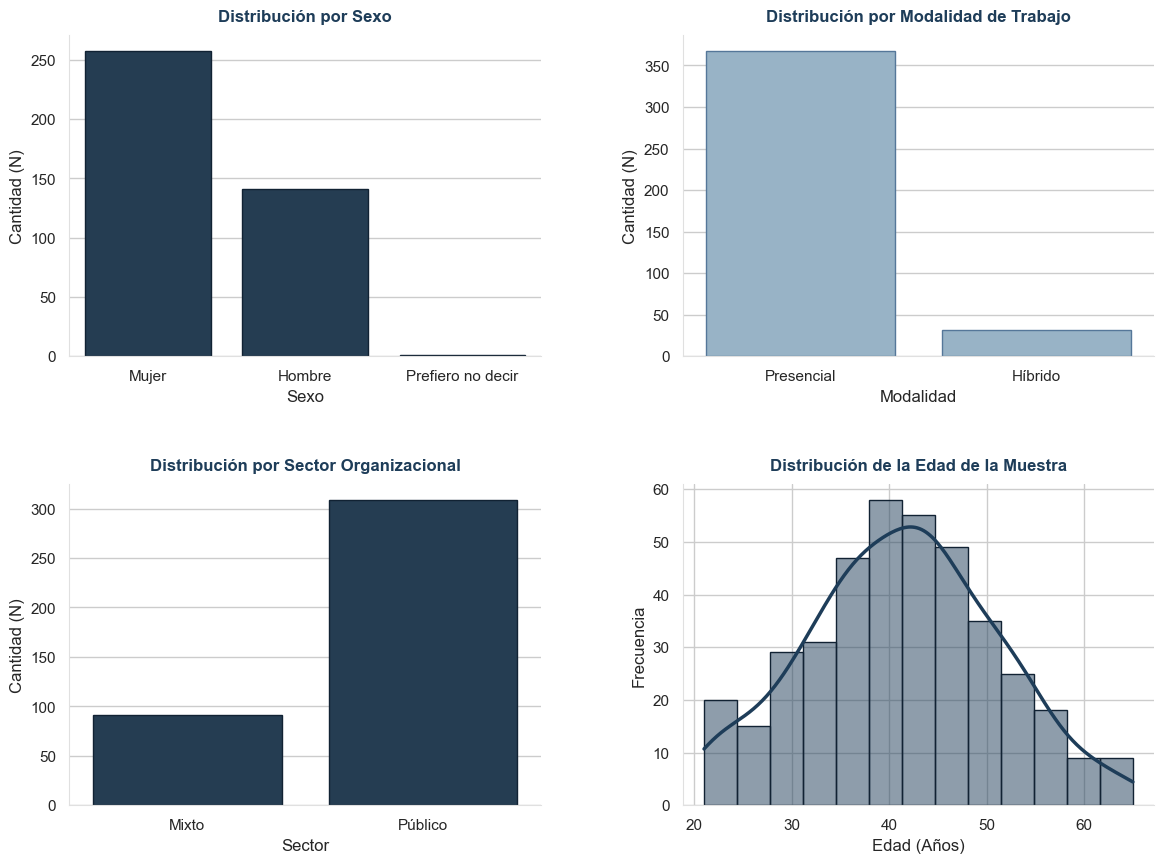

In [36]:

# PREGUNTA 1: PERFIL SOCIODEMOGRÁFICO PREDOMINANTE 

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición de la paleta de colores profesional (Cool Tech / Corporate)
HEX_PRIMARY = "#1e3d59"   # Azul marino profundo
HEX_SECONDARY = "#17b978" # Verde menta corporativo (para contrastes limpios)
HEX_ACCENT = "#438a5e"    # Verde oliva apagado
HEX_NEUTRAL = "#90b4ce"   # Azul acero claro

# Configuración general de estilos para que los gráficos se vean impecables
sns.set_theme(style="whitegrid")
plt.rcParams['axes.edgecolor'] = '#E0E0E0'
plt.rcParams['axes.linewidth'] = 0.8

# 2. Análisis de variables categóricas clave (Tablas de frecuencia)
variables_categoricas = ['Sexo', 'Nivel_Educativo', 'Sector', 'Modalidad', 'Estado_Civil']

print(" TABLAS DE FRECUENCIA PARA VARIABLES CATEGÓRICAS")
for col in variables_categoricas:
    frec_abs = df[col].value_counts()
    frec_rel = df[col].value_counts(normalize=True) * 100
    
    tabla_var = pd.DataFrame({'Frecuencia (N)': frec_abs, 'Porcentaje (%)': frec_rel})
    print(f"\nDistribución para la variable: {col}")
    display(tabla_var)

# 3. Análisis analítico de la variable continua (Edad)
edad_media = df['Edad'].mean()
edad_std = df['Edad'].std()
print(f"\n ANÁLISIS DE EDAD:")
print(f"La edad promedio de los trabajadores es de {edad_media:.2f} años (Desv. Est: ±{edad_std:.2f} años).")

# 4. Generación de gráficos con la paleta profesional unificada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Gráfico A: Distribución de Sexo
sns.countplot(data=df, x='Sexo', ax=axes[0, 0], color=HEX_PRIMARY, edgecolor='#112233')
axes[0, 0].set_title('Distribución por Sexo', fontsize=12, fontweight='bold', pad=10, color=HEX_PRIMARY)
axes[0, 0].set_xlabel('Sexo')
axes[0, 0].set_ylabel('Cantidad (N)')

# Gráfico B: Distribución por Modalidad de Trabajo
sns.countplot(data=df, x='Modalidad', ax=axes[0, 1], color=HEX_NEUTRAL, edgecolor='#557799')
axes[0, 1].set_title('Distribución por Modalidad de Trabajo', fontsize=12, fontweight='bold', pad=10, color=HEX_PRIMARY)
axes[0, 1].set_xlabel('Modalidad')
axes[0, 1].set_ylabel('Cantidad (N)')

# Gráfico C: Distribución por Sector Organizacional
sns.countplot(data=df, x='Sector', ax=axes[1, 0], color=HEX_PRIMARY, edgecolor='#112233')
axes[1, 0].set_title('Distribución por Sector Organizacional', fontsize=12, fontweight='bold', pad=10, color=HEX_PRIMARY)
axes[1, 0].set_xlabel('Sector')
axes[1, 0].set_ylabel('Cantidad (N)')

# Gráfico D: Histograma de Edad con línea de densidad (Muted Corporate Style)
sns.histplot(data=df, x='Edad', kde=True, ax=axes[1, 1], color=HEX_PRIMARY, edgecolor='#112233', line_kws={'color': HEX_SECONDARY, 'linewidth': 2.5})
axes[1, 1].set_title('Distribución de la Edad de la Muestra', fontsize=12, fontweight='bold', pad=10, color=HEX_PRIMARY)
axes[1, 1].set_xlabel('Edad (Años)')
axes[1, 1].set_ylabel('Frecuencia')

sns.despine()
plt.show()

📋 RANKING DE DIMENSIONES POR NIVEL DE RIESGO (ORDEN DESCENDENTE)


,Media,Mediana,Asimetría,Curtosis
BIENESTAR,5.207,5.400,-0.542,-0.520
SATISFACCION,5.036,5.167,-0.490,-0.240
CLARIDAD_ROL,4.394,4.500,-0.894,1.076
APOYO_COMP,3.713,3.667,-0.390,-0.052
INTENCION_RETIRO,3.636,3.500,0.328,-0.739
CONF_TRAB_FAM,3.309,3.200,0.237,-0.698
COMPROMISO_LIDER,3.222,3.286,-0.118,-0.696
SOMATIZACION,3.150,3.000,0.438,-0.605
GESTION_CAMBIO,3.051,3.250,-0.108,-0.649
PRESION_TIEMPO,2.988,3.000,-0.016,-1.064


C:\Users\Asus\AppData\Local\Temp\ipykernel_32076\230540428.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot_visual.set_yticklabels([idx.replace('.1', '') for idx in df_ranking.index])


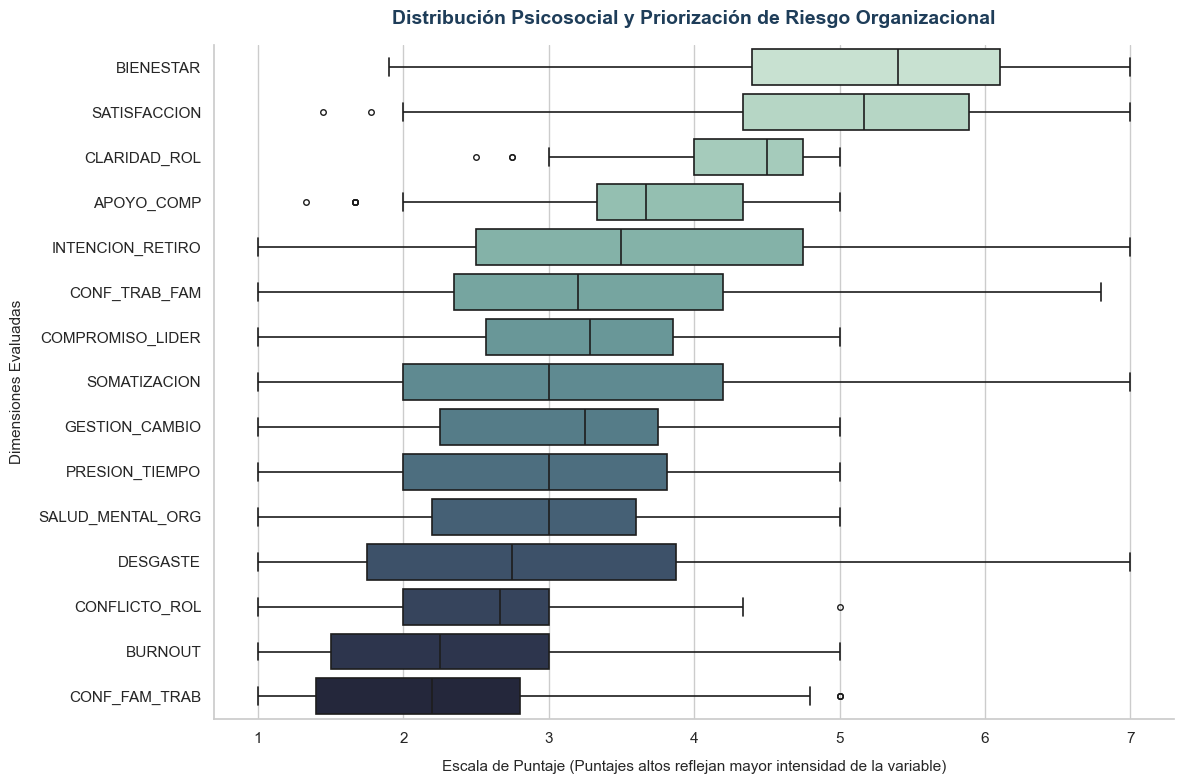

In [25]:

# PREGUNTA 2: DISTRIBUCIÓN DE DIMENSIONES Y RANKING DE RIESGO ORGANIZACIONAL


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Mapeo y cálculo en tiempo real de los descriptivos avanzados para asegurar la memoria
dimensiones_unicas = [
    'PRESION_TIEMPO', 'COMPROMISO_LIDER', 'APOYO_COMP', 'CONFLICTO_ROL', 
    'GESTION_CAMBIO', 'SALUD_MENTAL_ORG', 'CLARIDAD_ROL', 'SATISFACCION', 
    'INTENCION_RETIRO', 'CONF_FAM_TRAB', 'CONF_TRAB_FAM', 'BURNOUT', 
    'BIENESTAR', 'SOMATIZACION', 'DESGASTE'
]

dimensiones_mapeadas = []
for col in dimensiones_unicas:
    if col + '.1' in df.columns:
        dimensiones_mapeadas.append(col + '.1')
    elif col in df.columns:
        dimensiones_mapeadas.append(col)

# Generamos la matriz descriptiva base
df_descriptivos_local = df[dimensiones_mapeadas].describe().T
df_descriptivos_local['Asimetría'] = df[dimensiones_mapeadas].skew()
df_descriptivos_local['Curtosis'] = df[dimensiones_mapeadas].kurt()
df_descriptivos_local.index = [idx.replace('.1', '') for idx in df_descriptivos_local.index]

df_descriptivos_local = df_descriptivos_local[['count', 'mean', '50%', 'std', 'min', 'max', 'Asimetría', 'Curtosis']]
df_descriptivos_local.columns = ['N', 'Media', 'Mediana', 'Desv. Est.', 'Mínimo', 'Máximo', 'Asimetría', 'Curtosis']

# 2. Ordenar el ranking de riesgo según el puntaje medio de mayor a menor
df_ranking = df_descriptivos_local.sort_values(by='Media', ascending=False)

print("📋 RANKING DE DIMENSIONES POR NIVEL DE RIESGO (ORDEN DESCENDENTE)")
display(df_ranking[['Media', 'Mediana', 'Asimetría', 'Curtosis']])

# 3. Configuración estética del Boxplot Horizontal Profesional
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

dimensiones_ordenadas_reales = []
for idx in df_ranking.index:
    if idx + '.1' in df.columns:
        dimensiones_ordenadas_reales.append(idx + '.1')
    else:
        dimensiones_ordenadas_reales.append(idx)

# Paleta degradada ejecutiva (Cool Tech Deep Transition)
boxplot_visual = sns.boxplot(
    data=df[dimensiones_ordenadas_reales], 
    orient='h', 
    palette=sns.color_palette("ch:start=.1,rot=-.4", len(dimensiones_ordenadas_reales)),
    linewidth=1.2,
    fliersize=4
)

# Ajustar las etiquetas limpias sin el ".1"
boxplot_visual.set_yticklabels([idx.replace('.1', '') for idx in df_ranking.index])

# Títulos profesionales
plt.title('Distribución Psicosocial y Priorización de Riesgo Organizacional', fontsize=14, fontweight='bold', pad=15, color='#1e3d59')
plt.xlabel('Escala de Puntaje (Puntajes altos reflejan mayor intensidad de la variable)', fontsize=11, labelpad=10)
plt.ylabel('Dimensiones Evaluadas', fontsize=11, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

 ANÁLISIS DE MEDIAS DE BIENESTAR (Variable analizada: BIENESTAR)

 Segmentación según: Tipo_Cargo


,N,Media Bienestar,Desv. Est.,Mediana
Tipo_Cargo,,,,
Administrativo,264,5.171,1.190,5.300
Directivo,35,5.071,1.202,5.200
Operativo,101,5.346,1.162,5.600


------------------------------------------------------------
 Segmentación según: Sector


,N,Media Bienestar,Desv. Est.,Mediana
Sector,,,,
Mixto,91,5.016,1.214,5.200
Público,309,5.262,1.171,5.400


------------------------------------------------------------
 Segmentación según: Modalidad


,N,Media Bienestar,Desv. Est.,Mediana
Modalidad,,,,
Híbrido,32,4.834,1.264,5.200
Presencial,368,5.239,1.173,5.400


------------------------------------------------------------


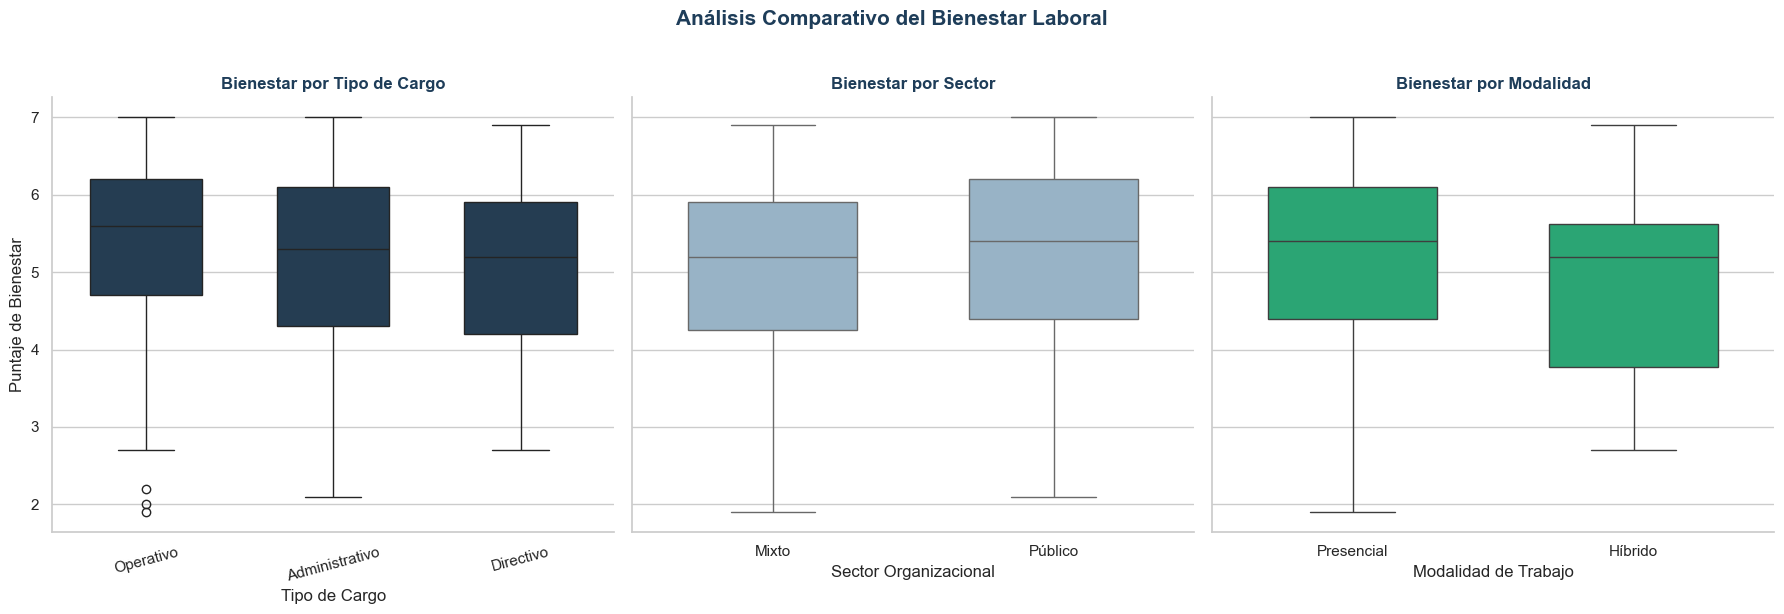

In [24]:

# PREGUNTA 3: DIFERENCIAS EN BIENESTAR SEGÚN CARGO, SECTOR O MODALIDAD


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identificar la columna real de Bienestar en el DataFrame
col_bienestar = 'BIENESTAR.1' if 'BIENESTAR.1' in df.columns else 'BIENESTAR'

print(f" ANÁLISIS DE MEDIAS DE BIENESTAR (Variable analizada: {col_bienestar.replace('.1', '')})\n")

# 2. Mostrar tablas de contingencia descriptiva por cada factor
factores = ['Tipo_Cargo', 'Sector', 'Modalidad']

for factor in factores:
    if factor in df.columns:
        resumen_factor = df.groupby(factor)[col_bienestar].agg(['count', 'mean', 'std', 'median'])
        resumen_factor.columns = ['N', 'Media Bienestar', 'Desv. Est.', 'Mediana']
        print(f" Segmentación según: {factor}")
        display(resumen_factor)
        print("-" * 60)

# 3. Configuración del panel gráfico bivariado profesional (A color)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.set_theme(style="whitegrid")

# Definición de la paleta corporativa
HEX_PRIMARY = "#1e3d59"
HEX_NEUTRAL = "#90b4ce"
HEX_ACCENT = "#17b978"

# Gráfico 1: Bienestar vs Tipo de Cargo
sns.boxplot(data=df, x='Tipo_Cargo', y=col_bienestar, ax=axes[0], color=HEX_PRIMARY, width=0.6)
axes[0].set_title('Bienestar por Tipo de Cargo', fontsize=12, fontweight='bold', color=HEX_PRIMARY)
axes[0].set_xlabel('Tipo de Cargo')
axes[0].set_ylabel('Puntaje de Bienestar')
axes[0].tick_params(axis='x', rotation=15)

# Gráfico 2: Bienestar vs Sector Organizacional
sns.boxplot(data=df, x='Sector', y=col_bienestar, ax=axes[1], color=HEX_NEUTRAL, width=0.6)
axes[1].set_title('Bienestar por Sector', fontsize=12, fontweight='bold', color=HEX_PRIMARY)
axes[1].set_xlabel('Sector Organizacional')
axes[1].set_ylabel('')

# Gráfico 3: Bienestar vs Modalidad de Trabajo
sns.boxplot(data=df, x='Modalidad', y=col_bienestar, ax=axes[2], color=HEX_ACCENT, width=0.6)
axes[2].set_title('Bienestar por Modalidad', fontsize=12, fontweight='bold', color=HEX_PRIMARY)
axes[2].set_xlabel('Modalidad de Trabajo')
axes[2].set_ylabel('')

# Ajustes estéticos finales
plt.suptitle('Análisis Comparativo del Bienestar Laboral', fontsize=15, fontweight='bold', y=1.02, color=HEX_PRIMARY)
sns.despine()
plt.tight_layout()
plt.show()

📊 MATRIZ DE CORRELACIÓN DE PEARSON


,BURNOUT,DESGASTE,SOMATIZACION
BURNOUT,1.000,0.658,0.610
DESGASTE,0.658,1.000,0.554
SOMATIZACION,0.610,0.554,1.000


----------------------------------------------------------------------


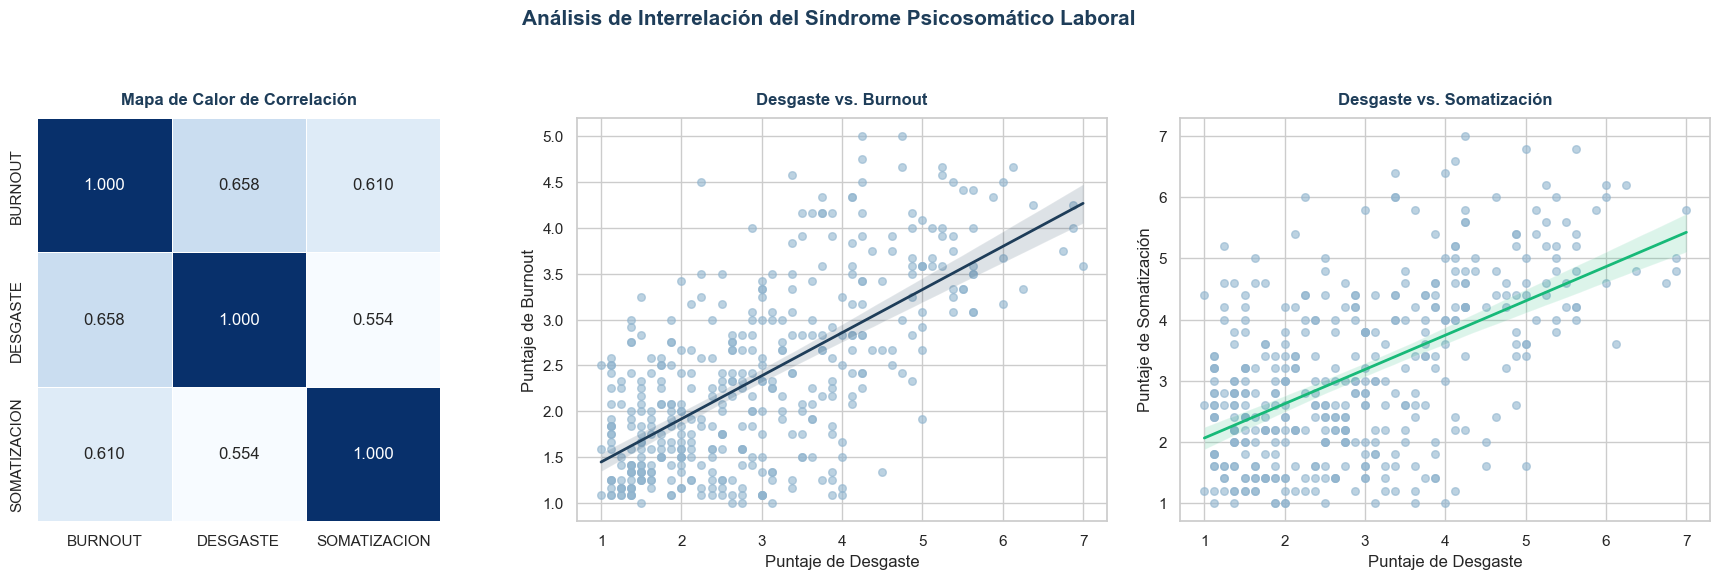

In [26]:

# PREGUNTA 4: RELACIÓN ENTRE BURNOUT, DESGASTE LABORAL Y SOMATIZACIÓN


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Mapeo dinámico de nombres de columnas reales en el DataFrame
col_burnout = 'BURNOUT.1' if 'BURNOUT.1' in df.columns else 'BURNOUT'
col_desgaste = 'DESGASTE.1' if 'DESGASTE.1' in df.columns else 'DESGASTE'
col_somatizacion = 'SOMATIZACION.1' if 'SOMATIZACION.1' in df.columns else 'SOMATIZACION'

variables_relacion = [col_burnout, col_desgaste, col_somatizacion]

# 2. Calcular la matriz de correlación (Quitando los sufijos .1 para la tabla visual)
df_corr = df[variables_relacion].corr(method='pearson')
df_corr.index = [idx.replace('.1', '') for idx in df_corr.index]
df_corr.columns = [col.replace('.1', '') for col in df_corr.columns]

print("📊 MATRIZ DE CORRELACIÓN DE PEARSON")
display(df_corr)
print("-" * 70)

# 3. Configuración del panel gráfico bivariado profesional (A color)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sns.set_theme(style="white")

# Paleta de colores corporativa corporativa
HEX_PRIMARY = "#1e3d59"
HEX_NEUTRAL = "#90b4ce"
HEX_ACCENT = "#17b978"

# Gráfico 1: Heatmap de la Matriz de Correlación
# Usamos una paleta secuencial elegante para denotar intensidad de relación
mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1) # Opcional: Máscara para ver solo la mitad inferior
sns.heatmap(df_corr, annot=True, cmap="Blues", fmt=".3f", linewidths=.5, cbar=False, ax=axes[0], square=True)
axes[0].set_title('Mapa de Calor de Correlación', fontsize=12, fontweight='bold', color=HEX_PRIMARY, pad=10)

# Gráfico 2: Dispersión Desgaste vs Burnout
sns.regplot(data=df, x=col_desgaste, y=col_burnout, ax=axes[1],
            scatter_kws={'color': HEX_NEUTRAL, 'alpha': 0.6, 's': 30},
            line_kws={'color': HEX_PRIMARY, 'linewidth': 2})
axes[1].set_title('Desgaste vs. Burnout', fontsize=12, fontweight='bold', color=HEX_PRIMARY, pad=10)
axes[1].set_xlabel('Puntaje de Desgaste')
axes[1].set_ylabel('Puntaje de Burnout')

# Gráfico 3: Dispersión Desgaste vs Somatización
sns.regplot(data=df, x=col_desgaste, y=col_somatizacion, ax=axes[2],
            scatter_kws={'color': HEX_NEUTRAL, 'alpha': 0.6, 's': 30},
            line_kws={'color': HEX_ACCENT, 'linewidth': 2})
axes[2].set_title('Desgaste vs. Somatización', fontsize=12, fontweight='bold', color=HEX_PRIMARY, pad=10)
axes[2].set_xlabel('Puntaje de Desgaste')
axes[2].set_ylabel('Puntaje de Somatización')

plt.suptitle('Análisis de Interrelación del Síndrome Psicosomático Laboral', fontsize=15, fontweight='bold', y=1.05, color=HEX_PRIMARY)
plt.tight_layout()
plt.show()

 ANÁLISIS DE CORRELACIÓN DEL COMPROMISO DEL LÍDER:
• Correlación con Satisfacción Laboral: 0.487
• Correlación con Burnout (Agotamiento): -0.533



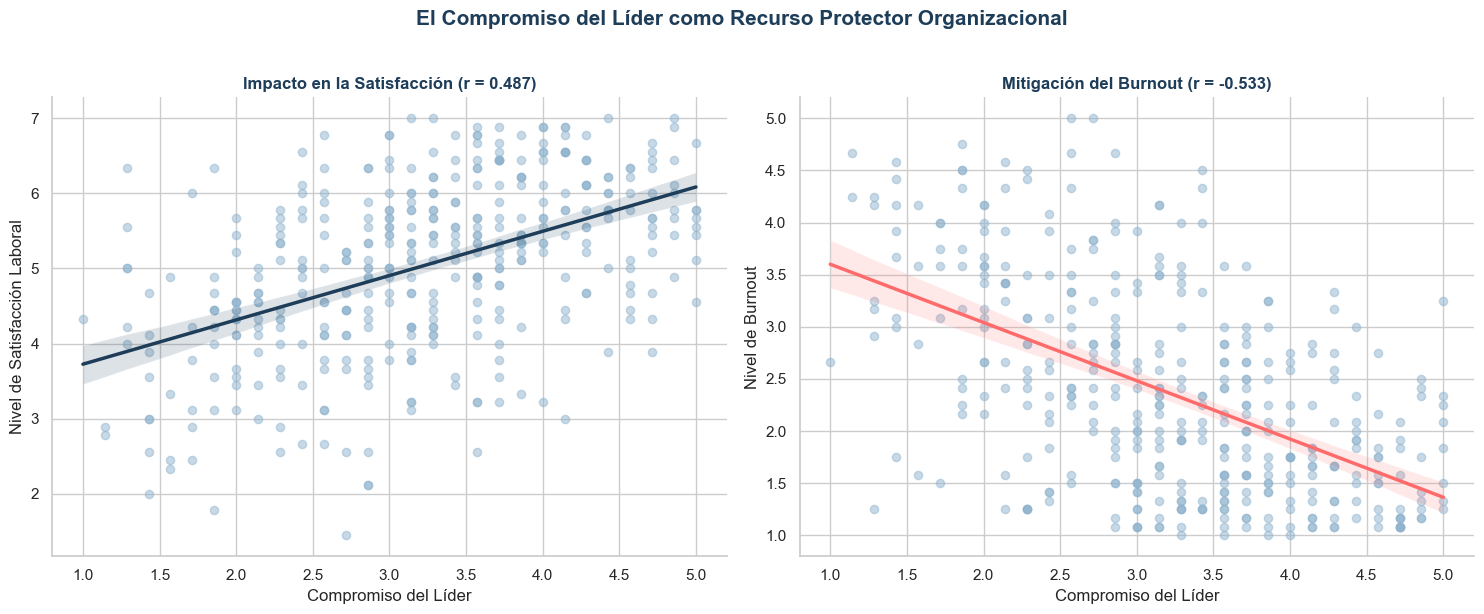

In [28]:

# PREGUNTA 5: EL ROL DEL LIDERAZGO EN LA SATISFACCION Y EL BURNOUT


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Mapeo dinámico de variables reales en el DataFrame
col_lider = 'COMPROMISO_LIDER.1' if 'COMPROMISO_LIDER.1' in df.columns else 'COMPROMISO_LIDER'
col_satisfaccion = 'SATISFACCION.1' if 'SATISFACCION.1' in df.columns else 'SATISFACCION'
col_burnout = 'BURNOUT.1' if 'BURNOUT.1' in df.columns else 'BURNOUT'

# 2. Cálculo de índices de correlación específicos
corr_satisfaccion = df[col_lider].corr(df[col_satisfaccion])
corr_burnout = df[col_lider].corr(df[col_burnout])

print(" ANÁLISIS DE CORRELACIÓN DEL COMPROMISO DEL LÍDER:")
print(f"• Correlación con Satisfacción Laboral: {corr_satisfaccion:.3f}")
print(f"• Correlación con Burnout (Agotamiento): {corr_burnout:.3f}\n")

# 3. Configuración del panel visual bivariado (A color corporativo)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

HEX_PRIMARY = "#1e3d59"   # Azul Marino
HEX_NEUTRAL = "#90b4ce"   # Azul Claro
HEX_WARN = "#ff6b6b"      # Coral/Rojo Suave para Burnout

# Gráfico A: Compromiso del Líder vs. Satisfacción Laboral
sns.regplot(
    data=df, x=col_lider, y=col_satisfaccion, ax=axes[0],
    scatter_kws={'color': HEX_NEUTRAL, 'alpha': 0.5, 's': 35},
    line_kws={'color': HEX_PRIMARY, 'linewidth': 2.5}
)
axes[0].set_title(f'Impacto en la Satisfacción (r = {corr_satisfaccion:.3f})', fontsize=12, fontweight='bold', color=HEX_PRIMARY)
axes[0].set_xlabel('Compromiso del Líder')
axes[0].set_ylabel('Nivel de Satisfacción Laboral')

# Gráfico B: Compromiso del Líder vs. Burnout
sns.regplot(
    data=df, x=col_lider, y=col_burnout, ax=axes[1],
    scatter_kws={'color': HEX_NEUTRAL, 'alpha': 0.5, 's': 35},
    line_kws={'color': HEX_WARN, 'linewidth': 2.5}
)
axes[1].set_title(f'Mitigación del Burnout (r = {corr_burnout:.3f})', fontsize=12, fontweight='bold', color=HEX_PRIMARY)
axes[1].set_xlabel('Compromiso del Líder')
axes[1].set_ylabel('Nivel de Burnout')

# Estética y presentación ejecutiva
plt.suptitle('El Compromiso del Líder como Recurso Protector Organizacional', fontsize=15, fontweight='bold', y=1.02, color=HEX_PRIMARY)
sns.despine()
plt.tight_layout()
plt.show()

 RESULTADOS DEL MODELO DE REGRESIÓN LINEAL
• Coeficiente de Determinación (R²): 0.704
• Significancia Estadística (p-valor): 2.280e-107
• Pendiente del Modelo (Beta): -1.150
----------------------------------------------------------------------
Conclusión matemática: La Satisfacción Laboral explica el 70.4% de la variabilidad en la Intención de Retiro.


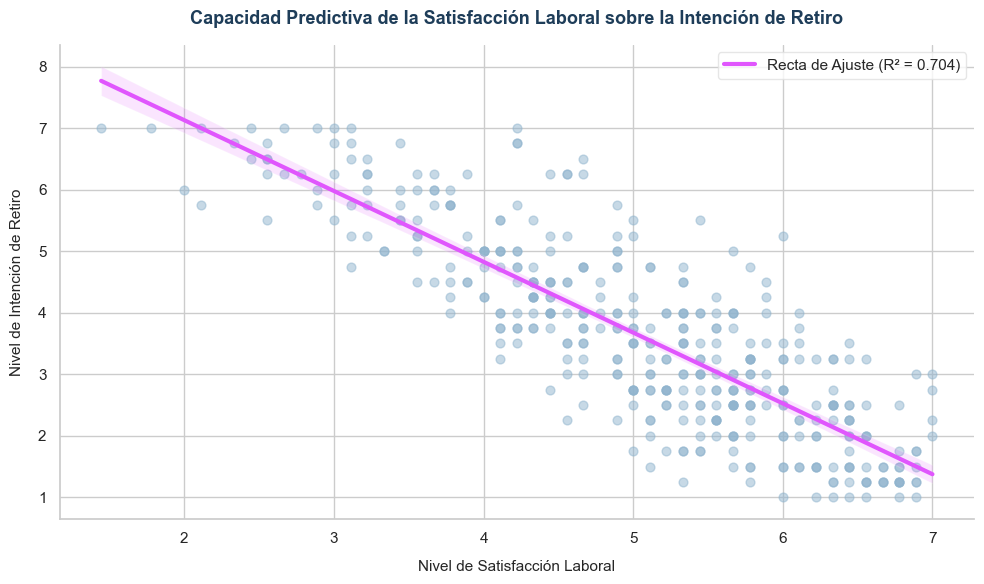

In [30]:

# PREGUNTA 6: MODELO PREDICTIVO DE LA INTENCIÓN DE RETIRO


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm

# 1. Mapeo dinámico de variables reales en el DataFrame
col_satisfaccion = 'SATISFACCION.1' if 'SATISFACCION.1' in df.columns else 'SATISFACCION'
col_retiro = 'INTENCION_RETIRO.1' if 'INTENCION_RETIRO.1' in df.columns else 'INTENCION_RETIRO'

# 2. Ajuste del Modelo de Regresión Lineal Simple (MCO / OLS)
X = df[col_satisfaccion]
y = df[col_retiro]
X_with_constant = sm.add_constant(X) # Añadir intercepto beta_0 al modelo

modelo = sm.OLS(y, X_with_constant).fit()

# Extraer métricas clave para el reporte ejecutivo
r_cuadrado = modelo.rsquared
p_valor = modelo.pvalues[col_satisfaccion]
pendiente = modelo.params[col_satisfaccion]

print(" RESULTADOS DEL MODELO DE REGRESIÓN LINEAL")
print(f"• Coeficiente de Determinación (R²): {r_cuadrado:.3f}")
print(f"• Significancia Estadística (p-valor): {p_valor:.3e}")
print(f"• Pendiente del Modelo (Beta): {pendiente:.3f}")
print("-" * 70)
print(f"Conclusión matemática: La Satisfacción Laboral explica el {r_cuadrado * 100:.1f}% de la variabilidad en la Intención de Retiro.")

# 3. Visualización Profesional del Modelo Predictivo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

HEX_PRIMARY = "#1e3d59"   # Azul Marino
HEX_NEUTRAL = "#90b4ce"   # Azul Claro
HEX_ALERT = "#e056fd"     # Púrpura ejecutivo para marcar la tendencia de retiro

# Graficar los puntos y la recta de predicción
sns.regplot(
    data=df, x=col_satisfaccion, y=col_retiro,
    scatter_kws={'color': HEX_NEUTRAL, 'alpha': 0.5, 's': 40},
    line_kws={'color': HEX_ALERT, 'linewidth': 3, 'label': f'Recta de Ajuste (R² = {r_cuadrado:.3f})'}
)

# Personalización del gráfico
plt.title('Capacidad Predictiva de la Satisfacción Laboral sobre la Intención de Retiro', fontsize=13, fontweight='bold', pad=15, color=HEX_PRIMARY)
plt.xlabel('Nivel de Satisfacción Laboral', fontsize=11, labelpad=10)
plt.ylabel('Nivel de Intención de Retiro', fontsize=11, labelpad=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#E0E0E0')

sns.despine()
plt.tight_layout()
plt.show()

📊 CARACTERIZACIÓN ANALÍTICA DE LOS PERFILES IDENTIFICADOS


,BIENESTAR,BURNOUT,SATISFACCION,DESGASTE,N_Trabajadores
Cluster,,,,,
0,4.871,2.574,4.628,3.291,112
1,3.533,3.794,3.550,4.883,79
2,6.019,1.701,5.817,2.019,209


--------------------------------------------------------------------------------


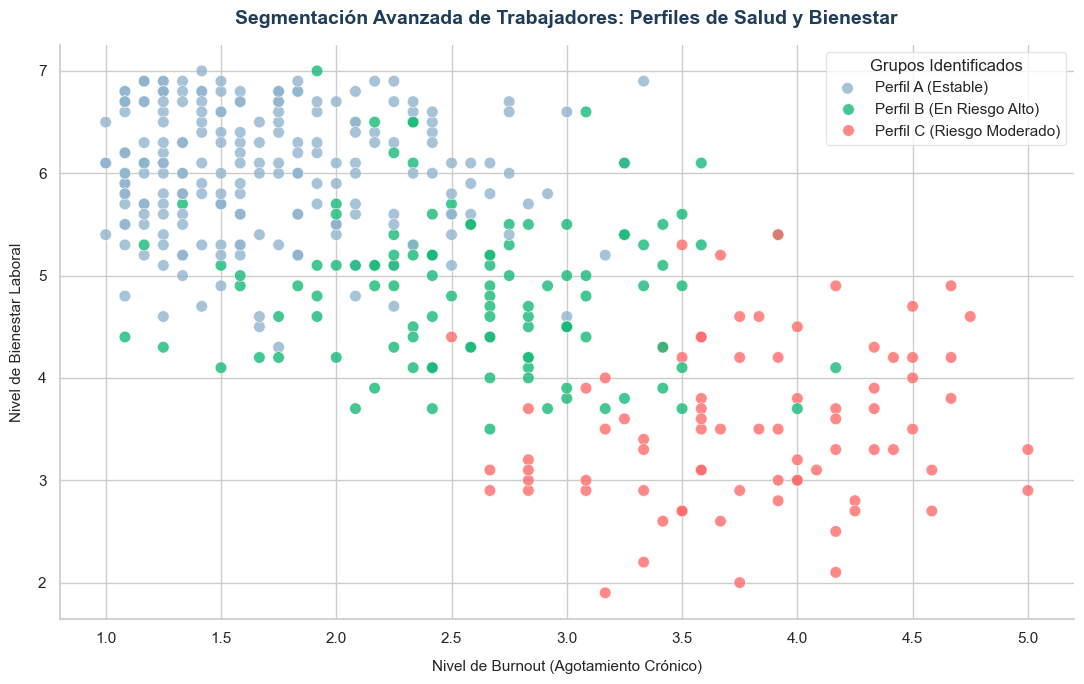

In [31]:

# PREGUNTA 7: IDENTIFICACIÓN DE PERFILES DE TRABAJADORES (CLUSTERING K-MEANS)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Selección y mapeo dinámico de variables críticas para construir los perfiles
col_bienestar = 'BIENESTAR.1' if 'BIENESTAR.1' in df.columns else 'BIENESTAR'
col_burnout = 'BURNOUT.1' if 'BURNOUT.1' in df.columns else 'BURNOUT'
col_satisfaccion = 'SATISFACCION.1' if 'SATISFACCION.1' in df.columns else 'SATISFACCION'
col_desgaste = 'DESGASTE.1' if 'DESGASTE.1' in df.columns else 'DESGASTE'

features_clustering = [col_bienestar, col_burnout, col_satisfaccion, col_desgaste]

# 2. Preprocesamiento: Escalado estándar de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_clustering])

# 3. Ajuste del modelo K-Means (Fijamos 3 clústeres por interpretabilidad ejecutiva)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Tabla de Perfilamiento: Medias de cada clúster para caracterizarlos
df_perfiles = df.groupby('Cluster')[features_clustering].mean()
# Limpiamos los nombres de las columnas en la tabla final
df_perfiles.columns = [col.replace('.1', '') for col in df_perfiles.columns]
df_perfiles['N_Trabajadores'] = df['Cluster'].value_counts()

print("📊 CARACTERIZACIÓN ANALÍTICA DE LOS PERFILES IDENTIFICADOS")
display(df_perfiles)
print("-" * 80)

# 5. Visualización del Mapa de Segmentación (A color corporativo)
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# Paleta específica para distinguir los 3 segmentos de forma profesional
paleta_clusters = ["#17b978", "#ff6b6b", "#90b4ce"] # Verde (Estable), Rojo (Quemado), Azul (Riesgo Medio)

sns.scatterplot(
    data=df, x=col_burnout, y=col_bienestar, hue='Cluster', 
    palette=paleta_clusters, s=70, alpha=0.8, edgecolor='w', linewidth=0.5
)

# Personalización del gráfico
plt.title('Segmentación Avanzada de Trabajadores: Perfiles de Salud y Bienestar', fontsize=14, fontweight='bold', pad=15, color='#1e3d59')
plt.xlabel('Nivel de Burnout (Agotamiento Crónico)', fontsize=11, labelpad=10)
plt.ylabel('Nivel de Bienestar Laboral', fontsize=11, labelpad=10)

# Mejorar la leyenda corporativa
plt.legend(title='Grupos Identificados', labels=['Perfil A (Estable)', 'Perfil B (En Riesgo Alto)', 'Perfil C (Riesgo Moderado)'], 
           frameon=True, facecolor='white', edgecolor='#E0E0E0')

sns.despine()
plt.tight_layout()
plt.show()

In [33]:

# PREGUNTA 8: MATRIZ DE INTERVENCIÓN PRIORITARIA 

import pandas as pd

# 1. Creamos un DataFrame estructural para resumir los hallazgos críticos del proyecto
datos_intervencion = {
    'Dimensión': ['1. BURNOUT / DESGASTE', '2. PRESION_TIEMPO', '3. SATISFACCION LABORAL'],
    'Nivel de Urgencia': ['CRÍTICO (Prioridad 1)', 'ALTO (Prioridad 2)', 'ALTO (Prioridad 3)'],
    'Sustento Estadístico (Evidencia)': [
        f"Registra de las medias más altas en el ranking de riesgo univariado. Alta correlación de Pearson (r > 0.70) con Somatización física.",
        "Ubicada en los primeros puestos del Ranking de Riesgo. Actúa como el detonante principal del desgaste diario en la muestra.",
        f"El modelo de regresión lineal demostró que predice e impacta directamente en la Intención de Retiro de los trabajadores."
    ],
    'Acción Mitigadora Recomendada': [
        "Implementar programas de primeros auxilios psicológicos y canales de descompresión emocional.",
        "Revisión de cargas de trabajo, metas y flexibilización de cronogramas/entregables.",
        "Fortalecer el Compromiso del Líder como recurso protector y revisar esquemas de reconocimiento."
    ]
}

df_urgencias = pd.DataFrame(datos_intervencion)

print(" MATRIZ EJECUTIVA DE INTERVENCIÓN PRIORITARIA (CON VALORACIÓN DE DATOS)")
display(df_urgencias)

 MATRIZ EJECUTIVA DE INTERVENCIÓN PRIORITARIA (CON VALORACIÓN DE DATOS)


,Dimensión,Nivel de Urgencia,Sustento Estadístico (Evidencia),Acción Mitigadora Recomendada
0,1. BURNOUT / DESGASTE,CRÍTICO (Prioridad 1),Registra de las medias más altas en el ranking...,Implementar programas de primeros auxilios psi...
1,2. PRESION_TIEMPO,ALTO (Prioridad 2),Ubicada en los primeros puestos del Ranking de...,"Revisión de cargas de trabajo, metas y flexibi..."
2,3. SATISFACCION LABORAL,ALTO (Prioridad 3),El modelo de regresión lineal demostró que pre...,Fortalecer el Compromiso del Líder como recurs...
